# Introduction 
In 2023, Rite Aid, one of the nation’s largest pharmacy chains, announced its initial filing for bankruptcy. At that time, the company revealed plans to begin a gradual process of downsizing its retail presence.  By 2025, Rite Aid confirmed that it would close more than 1,000 stores with more than 300 of these closures being located in Pennsylvania. Pharmacy closures and transfers often reshape patterns of access in ways that disproportionately affect vulnerable populations. Research has shown that transfer pharmacies are typically located farther from the original sites, creating what scholars describe as “pharmacy deserts” where residents must travel longer distances to obtain essential medications. These relocations are especially consequential for certain demographics vulnerable to increased distance such as elderly adults, residents without vehicles, and individuals with disabilities. This analysis measures the distance between former and transfer pharmacy locations as a proxy for resident burden. To further contextualize these distance measures, vulnerable populations served at both former and newer locations were estimated. This dual approach allowed for an understanding of not only whether pharmacies were farther away after transfers, but also whether vulnerable groups experienced disproportionate changes in accessibility.

# Methods
## 1. Data Collection 
### 1.1 Web-Scraping

Information on Rite Aid closures is often fragmented and outdated, with most sources consisting of opinion pieces or scattered news articles that lack precise details on the affected locations. Official data, such as the City of Philadelphia’s pharmacy list, is also unreliable, having last been updated in 2019. The Rite Aid website itself provides only a static table of transfer pharmacies paired with former Rite Aid stores, along with a link for requesting medical records. 

<div style="text-align: center;">
<img src="./data/full_pharmacy_table.png" width="800"/>
</div>

To enable spatial analysis of these closures, I parsed the webpage’s HTML to extract the addresses of both the closed Rite Aid stores and their corresponding transfer pharmacies.

In [1]:
# Library Set Up
# Web-Scraping and External Data Gathering
from selenium import webdriver
from bs4 import BeautifulSoup
import cenpy 
import pygris
import requests

# Geographic Data Gathering
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import osmnx as ox
import networkx as nx

# Data Formatting and Manipulation 
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import re

# Plotting 
from matplotlib import pyplot as plt
import seaborn as sns

C:\Users\Angel\anaconda3\envs\geospatial\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [2]:
# Launch Webpage
driver = webdriver.Edge()
driver.get("https://content.riteaid.com/new-pharmacy-location.html")


In [3]:
#| output: false
# Parse with element holding pharmacy information
soup = BeautifulSoup(driver.page_source, "html.parser")
table = soup.select_one("table.table.table-bordered")

# Extract rows
rows = []
for row in table.select("tr"):
    cells = [cell.get_text(strip=True) for cell in row.select("td, th")]
    rows.append(cells)

# Convert to DataFrame
pharmacies_df = pd.DataFrame(rows[1:], columns=rows[0])  # first row as header


The parsed table was restructured into two separate dataframes: one representing former Rite Aid locations and the other representing their corresponding transfer pharmacies. Each dataset maintains the correspondance between former and transfer pharamcy locations by attaching the former Rite Aid store number regardless of whether it was the new or old pharmacy. Because the analysis examined changes in distance between former and new pharmacies, two records were excluded. One was removed where a new pharmacy directly replaced the former at the same site, resulting in no change in travel distance. The other was excluded due to the transfer pharamcy being in a new city outside the study area.

<div style="text-align: center;">
<img src="./data/pharmacy_table_view.png" width="800"/>
</div>

In [4]:
#| output: false
# Separate pharmacies based on whether they are former or transfer locations 
old_pharm = pharmacies_df[["Store Number", 
                           "Old Pharmacy Name",
                           "Old Address", 
                           "Old City", 
                           "Old Zip"]]

new_pharm = pharmacies_df[["Store Number", 
                           "New Pharmacy Name",
                           "New Address", 
                           "New City", 
                           "New Zip"]]


# Filter for study area (Philadelphia) only 
old_pharm_phl = old_pharm[old_pharm["Old City"] == "PHILADELPHIA"]

new_pharm_phl = new_pharm[new_pharm["New City"] == "PHILADELPHIA"]


# Removed two addresses 
old_pharm_phl = old_pharm_phl[
    (old_pharm_phl["Old Address"] != "5627-99 CHESTNUT STREET") & #is the same store new and old
    (old_pharm_phl["Old Address"] != "5040 CITY LINE AVENUE") #isn't replaced by another store
]
new_pharm_phl = new_pharm_phl[
    new_pharm_phl["New Address"] != "5627-99 CHESTNUT STREET,"
]

In [5]:
#| output: false
# Created a function that preps addresses to properly formatted before being processes by geocoding function
def clean_address(addr):
    
    addr = re.sub(r"(\d+)-\d+", r"\1", str(addr))
    
    addr = re.sub(r"\s+(SUITE|UNIT)\s*\d*", "", addr, flags=re.IGNORECASE)
    
   
    addr = re.sub(r"(AVENUE|STREET)\s*PA", r"\1", addr, flags=re.IGNORECASE)
    
    return addr

old_pharm_phl["Old Address"] = old_pharm_phl["Old Address"].apply(clean_address)

new_pharm_phl["New Address"] = new_pharm_phl["New Address"].apply(clean_address)

# Concatenated the full addresses from the individual elements stored as columns 
old_pharm_phl["Full Address"] = (
    old_pharm_phl["Old Address"].astype(str) + ", " +
    old_pharm_phl["Old City"].astype(str) + ", " +
    "PA" + " " +
    old_pharm_phl["Old Zip"].astype(str)
)


new_pharm_phl["Full Address"] = (
    new_pharm_phl["New Address"].astype(str) + ", " +
    new_pharm_phl["New City"].astype(str) + ", " +
    "PA" + " " +
    new_pharm_phl["New Zip"].astype(str)
)

In [6]:
# Creating a neighborhood name column based on the addresses for graph readability 
neighborhood_map = {
    "11136": "Windrim Ave (Germantown)",
    "1941": "Ogontz Ave (West Oak Lane)",
    "7834": "Frankford Ave (Torresdale)",
    "872": "W Chelten Ave (Germantown)",
    "1956": "Academy Rd (Academy Gardens)",
    "3637": "Frankford Ave (Mayfair)",
    "1936": "S Broad St (South Philadelphia)",
    "11139": "Castor Ave (Oxford Circle)",
    "1766": "Snyder Ave (South Philadelphia)",
    "11126": "Frankford Ave (Holmesburg)",
    "11125": "Oxford Ave (Fox Chase)",
    "3825": "S 9th St (South Philadelphia)",
    "11141": "Woodhaven Rd (Torresdale)",
    "479": "Lindbergh Blvd (Eastwick)",
    "554": "Krewstown Rd (Somerton)",
    "3251": "Midvale Ave (East Falls)",
    "4938": "Castor Ave (Rhawnhurst)",
    "11130": "Crittenden St (Chestnut Hill)",
    "3434": "Fairmount Ave (Fairmount)",
    "3801": "E Passyunk Ave (South Philadelphia)",
    "822": "Ridge Ave (Roxborough)",
    "3325": "S 7th St (South Philadelphia)"
}

new_pharm_phl["Neighborhood Name"] = new_pharm_phl["Store Number"].astype(str).map(neighborhood_map)

new_pharm_phl

,Store Number,New Pharmacy Name,New Address,New City,New Zip,Full Address,Neighborhood Name
46,11136,WALGREENS,112 W CHELTEN AVE,PHILADELPHIA,19144,"112 W CHELTEN AVE, PHILADELPHIA, PA 19144",Windrim Ave (Germantown)
234,1941,CVS/PHARMACY,6344 STENTON AVENUE,PHILADELPHIA,19138,"6344 STENTON AVENUE, PHILADELPHIA, PA 19138",Ogontz Ave (West Oak Lane)
280,7834,CVS/PHARMACY,8525 FRANKFORD AVENUE,PHILADELPHIA,19136,"8525 FRANKFORD AVENUE, PHILADELPHIA, PA 19136",Frankford Ave (Torresdale)
332,872,WALGREENS,112 W CHELTEN AVE,PHILADELPHIA,19144,"112 W CHELTEN AVE, PHILADELPHIA, PA 19144",W Chelten Ave (Germantown)
333,1956,CVS/PHARMACY,12301 KNIGHTS ROAD,PHILADELPHIA,19154,"12301 KNIGHTS ROAD, PHILADELPHIA, PA 19154",Academy Rd (Academy Gardens)
358,3637,CVS/PHARMACY,6501 HARBISON AVENUE,PHILADELPHIA,19149,"6501 HARBISON AVENUE, PHILADELPHIA, PA 19149",Frankford Ave (Mayfair)
422,1936,CVS/PHARMACY,1405 SOUTH 10TH STREET,PHILADELPHIA,19147,"1405 SOUTH 10TH STREET, PHILADELPHIA, PA 19147",S Broad St (South Philadelphia)
520,11139,CVS/PHARMACY,6501 HARBISON AVENUE,PHILADELPHIA,19149,"6501 HARBISON AVENUE, PHILADELPHIA, PA 19149",Castor Ave (Oxford Circle)
592,1766,CVS/PHARMACY,1 MIFFLIN ST,PHILADELPHIA,19148,"1 MIFFLIN ST, PHILADELPHIA, PA 19148",Snyder Ave (South Philadelphia)
612,11126,CVS/PHARMACY,3331 GRANT AVE.,PHILADELPHIA,19114,"3331 GRANT AVE., PHILADELPHIA, PA 19114",Frankford Ave (Holmesburg)


### 1.2 Geocoding via Nominatim API

Old and new pharmacy addresses were geocoded using the Nominatim API to obtain latitude and longitude coordinates for distance calculations. Because no existing spatial dataset directly includes spatial information for former and transfer pharmacy locations, this step was essential to construct a usable dataset from scratch. Geocoding provided the spatial reference needed to calculate both walking and driving distances.

In [7]:
#| output: false
# Geocoded full addresses in order to get spatial data for pharmacies 
geolocator = Nominatim(user_agent="pharmacy_geocoder", timeout=10)

geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# Helper function that returns longitude and latitude 
def geocode_address(addr):
    try:
        location = geocode(addr)
        if location:
            return location.latitude, location.longitude
    except Exception as e:
        print(f"Error geocoding {addr}: {e}")
        return None, None
    return None, None


# Function that creates a dataframe and geometry column for geocoded addresses 
def add_geocoding(df, address_col):
    
    df["lat"] = None
    df["lon"] = None
    
    for idx, address in df[address_col].items():
        lat, lon = geocode_address(address)
        df.at[idx, "lat"] = lat
        df.at[idx, "lon"] = lon
    
    # Build geometry column
    df["geometry"] = [
        Point(lon, lat) if pd.notnull(lat) and pd.notnull(lon) else None
        for lat, lon in zip(df["lat"], df["lon"])
    ]
    
    return gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")


# Apply main geocode function to both new and old pharamacy dataframes
old_gdf = add_geocoding(old_pharm_phl, "Full Address")


new_gdf = add_geocoding(new_pharm_phl, "Full Address")

The interactive map below illustrates the results of geocoding the addresses of both former Rite Aid locations (red) and their designated transfer pharmacies (blue). 

In [8]:
# Interactive map of old and new pharmacies

m = old_gdf.explore(
    tiles="CartoDB positron",
    color="red", 
    marker_kwds=dict(radius=6),
    tooltip=False,
    popup=False, 
    name="Old Pharmacies",

)

new_gdf.explore(
    color="blue", 
    marker_kwds=dict(radius=6), 
    tooltip=False, 
    popup=False,
    name="New Pharmacies",
    m=m  
)

m

The visualization highlights that former Rite Aid locations were not evenly distributed across Philadelphia’s census tracts, influencing this analysis' spatial analysis to be anchored directly at location of pharmacies. This reframes this analysis' approach to capturing the localized disparities in service coverage.

### 1.3 Retrieving Census Data via Census API

Census tract–level data for Philadelphia was retrieved from the American Community Survey (ACS) using the Census API. This analysis takes inspiration from the social vulnerability index (SVI) which was developed by the Agency for Toxic Substances and Disease Registry (ATSDR) and Centers for Disease Control and Prevention (CDC)  to measure how vulnerable a community’s wellbeing is to major disruptive events such as natural disasters, disease outbreaks, or man-made environmental hazards. The SVI assigns percentile ranks to 16 variables from the 5‑year American Community Survey (ACS) that are associated with vulnerability. These variables are grouped into four themes: socioeconomic status, household characteristics, racial and ethnic minority status, and housing type and transportation. 


<div style="text-align: center;">
<img src="./data/svi-variable-table.png" width="600"/>
</div>


Each census tract receives a percentile rank for each variable and theme as well as one overall percentile ranking that indicating its relative vulnerability compared to other tracts. Rather than interpreting a composite measure, this analysis employs specific variables to more precisely assess the impact of distance on communities identified as theoretically significant. Specifically, variables representing households without a vehicle, individuals with a disability, and the population aged 65 and older were selected as indicators of groups most vulnerable to the effects of distance. 



In [9]:
#| output: false
# Use Census API to get census data
acs = cenpy.remote.APIConnection("ACSDT5Y2021")

PA_state_code = "42"

Philly_county_code = "101"

philly_census = acs.query(
    cols= ["NAME",
            "B01003_001E", # Total Population
            "B08201_002E", # Total No Vehicle 
            "C18108_002E", # Total Disabled
            "B01001_020E", # Males 65+
            "B01001_021E", 
            "B01001_022E", 
            "B01001_023E",
            "B01001_024E", 
            "B01001_025E",
            "B01001_044E", # Women 65+
            "B01001_045E", 
            "B01001_046E", 
            "B01001_047E", 
            "B01001_048E",
            "B01001_049E"],
    geo_unit= "tract",
    geo_filter={"state": PA_state_code,
                "county": Philly_county_code
               },
)

# Add the 65+ columns together 
philly_census["65_Population"] = philly_census[["B01001_020E", # Males 65+
                                             "B01001_021E", 
                                             "B01001_022E", 
                                             "B01001_023E",
                                             "B01001_024E", 
                                             "B01001_025E",
                                             "B01001_044E", # Women 65+
                                             "B01001_045E", 
                                             "B01001_046E", 
                                             "B01001_047E", 
                                             "B01001_048E",
                                             "B01001_049E"]].astype(int).sum(axis=1)

# Rename columns
philly_census = philly_census.rename(columns={"B01003_001E": "Total_Population",
                                             "B08201_002E": "Total_No_Vehicle", 
                                             "C18108_002E": "Total_Disabled"})

# Filter to renamed columns only for clarity
philly_census = philly_census[["NAME","tract","Total_Population", "Total_No_Vehicle", "Total_Disabled", "65_Population"]]

# Convert to integers for later calculations 
philly_census[["Total_Population", "Total_No_Vehicle", "Total_Disabled", "65_Population"]] = (
    philly_census[["Total_Population", "Total_No_Vehicle", "Total_Disabled", "65_Population"]].astype(int)
)

Census tract geometries were retrieved using Pygris which provides direct access to the census tract geometry data through the Census API.

In [10]:
#| output: false
philly_tracts = pygris.tracts(
    state= PA_state_code,
    county= Philly_county_code,
    year=2021
)

philly_census_tracts = philly_tracts.merge(
    philly_census,
    left_on= "TRACTCE",
    right_on= "tract",
)

# Reproj for buffer analysis
philly_census_tracts = philly_census_tracts.to_crs(2272)

## 2. Spatial Analysis
### 2.1 Calculating Pharmacy-to-Pharmacy Distance Using OSMnx and NetworkX 

Both driving and walking distances between former and new pharmacies were computed with OSMnx and NetworkX using the shortest path lengths on the respective street networks. These libraries allow for the calculation of realistic travel distances along actual street networks rather than simple straight‑line (Euclidean) distances, thus better reflecting the routes residents would take in practice. Within the context of pharmacy closures, there is a common understanding that transfer pharmacies are typically located farther from the original sites, and this analysis provides a systematic way to quantify those differences in terms of both walking and driving accessibility. This analysis also assumes residents are more likely to use the nearest available pharmacy, implying that a preference for a former pharmacy would correlate with greater distance traveled to a transfer pharmacy.

In [11]:
#| output: false
# Get street pedestrian and vehicle network for distance calculations
place = "Philadelphia, Pennsylvania, USA"

G_drive = ox.graph_from_place(place, network_type="drive")
G_walk = ox.graph_from_place(place, network_type="walk")

In [12]:
#| output: false
# Reproject to ensure the integrity of distance calculations 
Drive_reproj= ox.project_graph(
    G_drive,
    to_crs=2272,
    to_latlong=False
)

Walk_reproj = ox.project_graph(
    G_walk,
    to_crs=2272,
    to_latlong=False
)


old_reproj = old_gdf.to_crs(2272)
new_reproj = new_gdf.to_crs(2272)

In [13]:
#| output: false
# Nearest node is assigned to each pharmacy for both walking and driving networks
drive_old_nn = ox.distance.nearest_nodes( 
    Drive_reproj, 
    old_reproj.geometry.x, 
    old_reproj.geometry.y
)
drive_new_nn = ox.distance.nearest_nodes( 
    Drive_reproj, 
    new_reproj.geometry.x, 
    new_reproj.geometry.y
)


walk_new_nn = ox.distance.nearest_nodes( 
   Walk_reproj, 
    new_reproj.geometry.x, 
    new_reproj.geometry.y
)
walk_old_nn = ox.distance.nearest_nodes( 
    Walk_reproj, 
    old_reproj.geometry.x, 
    old_reproj.geometry.y
)

old_reproj["drive_node"] = drive_old_nn
new_reproj["drive_node"] = drive_new_nn

old_reproj["walk_node"] = walk_old_nn
new_reproj["walk_node"] = walk_new_nn

In [14]:
#| output: false
# Distance between paired pharmacy nodes calculated for both network types
drive_dists = [
    nx.shortest_path_length(Drive_reproj, o, n, weight="length")
    for o, n in zip(old_reproj["drive_node"], new_reproj["drive_node"])
]


walk_dists = [
    nx.shortest_path_length(Walk_reproj, o, n, weight="length")
    for o, n in zip(old_reproj["walk_node"], new_reproj["walk_node"])
]


old_reproj["drive_dist"] = drive_dists
old_reproj["walk_dist"] = walk_dists

new_reproj["drive_dist"] = drive_dists
new_reproj["walk_dist"] = walk_dists

old_reproj

,Store Number,Old Pharmacy Name,Old Address,Old City,Old Zip,Full Address,lat,lon,geometry,drive_node,walk_node,drive_dist,walk_dist
46,11136,RITE AID PHARMACY,1334 WINDRIM AVENUE,PHILADELPHIA,19141,"1334 WINDRIM AVENUE, PHILADELPHIA, PA 19141",40.029923,-75.145807,POINT (2697663.86 264509.326),109728243,7851207800,3131.120059,3140.780212
234,1941,RITE AID PHARMACY,7401 OGONTZ AVENUE,PHILADELPHIA,19138,"7401 OGONTZ AVENUE, PHILADELPHIA, PA 19138",40.067801,-75.156249,POINT (2694335.852 278215.608),110314209,5544799301,1512.232193,1418.778071
280,7834,RITE AID PHARMACY,9200 FRANKFORD AVENUE,PHILADELPHIA,19114,"9200 FRANKFORD AVENUE, PHILADELPHIA, PA 19114",40.0554,-75.004874,POINT (2736823.957 274981.112),4234641269,5561642625,1330.413143,1517.544642
332,872,RITE AID PHARMACY,164 WEST CHELTEN AVENUE,PHILADELPHIA,19144,"164 WEST CHELTEN AVENUE, PHILADELPHIA, PA 19144",40.032078,-75.178037,POINT (2688619.415 265029.486),110204807,5542789054,329.387098,275.373681
333,1956,RITE AID PHARMACY,12311 ACADEMY ROAD,PHILADELPHIA,19154,"12311 ACADEMY ROAD, PHILADELPHIA, PA 19154",40.095186,-74.97592,POINT (2744469.988 289720.515),1927949349,5543455523,1647.575443,1202.876908
358,3637,RITE AID PHARMACY,6363 FRANKFORD AVENUE,PHILADELPHIA,19135,"6363 FRANKFORD AVENUE, PHILADELPHIA, PA 19135",40.028027,-75.057952,POINT (2722276.619 264556.592),110029848,5550924976,1039.151408,1049.905549
422,1936,RITE AID PHARMACY,2017 SOUTH BROAD ST.,PHILADELPHIA,19148,"2017 SOUTH BROAD ST., PHILADELPHIA, PA 19148",39.924936,-75.169101,POINT (2692261.122 226089.082),110283892,5531577853,1086.357494,1121.228352
520,11139,RITE AID PHARMACY,6515 CASTOR AVENUE,PHILADELPHIA,19149,"6515 CASTOR AVENUE, PHILADELPHIA, PA 19149",40.040932,-75.075341,POINT (2717266.584 269107.548),110365749,5550925140,1787.983178,1412.375922
592,1766,RITE AID PHARMACY,10 SNYDER AVENUE,PHILADELPHIA,19148,"10 SNYDER AVENUE, PHILADELPHIA, PA 19148",39.9213,-75.146451,POINT (2698650.119 224951.659),110210515,10082982543,361.688268,354.683176
612,11126,RITE AID PHARMACY,9910 FRANKFORD AVENUE,PHILADELPHIA,19114,"9910 FRANKFORD AVENUE, PHILADELPHIA, PA 19114",40.064928,-74.984108,POINT (2742525.502 278631.554),4786724757,5184848167,2337.219028,2449.093896


In [15]:
new_reproj

,Store Number,New Pharmacy Name,New Address,New City,New Zip,Full Address,Neighborhood Name,lat,lon,geometry,drive_node,walk_node,drive_dist,walk_dist
46,11136,WALGREENS,112 W CHELTEN AVE,PHILADELPHIA,19144,"112 W CHELTEN AVE, PHILADELPHIA, PA 19144",Windrim Ave (Germantown),40.03359,-75.176879,POINT (2688927.451 265589.421),110316364,12563258418,3131.120059,3140.780212
234,1941,CVS/PHARMACY,6344 STENTON AVENUE,PHILADELPHIA,19138,"6344 STENTON AVENUE, PHILADELPHIA, PA 19138",Ogontz Ave (West Oak Lane),40.05989,-75.166541,POINT (2691540.84 275250.624),109731606,5544046731,1512.232193,1418.778071
280,7834,CVS/PHARMACY,8525 FRANKFORD AVENUE,PHILADELPHIA,19136,"8525 FRANKFORD AVENUE, PHILADELPHIA, PA 19136",Frankford Ave (Torresdale),40.045778,-75.015529,POINT (2733951.004 271385.147),4785186412,4060732044,1330.413143,1517.544642
332,872,WALGREENS,112 W CHELTEN AVE,PHILADELPHIA,19144,"112 W CHELTEN AVE, PHILADELPHIA, PA 19144",W Chelten Ave (Germantown),40.03359,-75.176879,POINT (2688927.451 265589.421),110316364,12563258418,329.387098,275.373681
333,1956,CVS/PHARMACY,12301 KNIGHTS ROAD,PHILADELPHIA,19154,"12301 KNIGHTS ROAD, PHILADELPHIA, PA 19154",Academy Rd (Academy Gardens),40.088521,-74.969979,POINT (2746207.666 287345.942),545316544,10755604884,1647.575443,1202.876908
358,3637,CVS/PHARMACY,6501 HARBISON AVENUE,PHILADELPHIA,19149,"6501 HARBISON AVENUE, PHILADELPHIA, PA 19149",Frankford Ave (Mayfair),40.03459,-75.063438,POINT (2720668.227 266899.567),4783712214,5550924769,1039.151408,1049.905549
422,1936,CVS/PHARMACY,1405 SOUTH 10TH STREET,PHILADELPHIA,19147,"1405 SOUTH 10TH STREET, PHILADELPHIA, PA 19147",S Broad St (South Philadelphia),39.931291,-75.161038,POINT (2694453.668 228469.366),110122460,4543624923,1086.357494,1121.228352
520,11139,CVS/PHARMACY,6501 HARBISON AVENUE,PHILADELPHIA,19149,"6501 HARBISON AVENUE, PHILADELPHIA, PA 19149",Castor Ave (Oxford Circle),40.03459,-75.063438,POINT (2720668.227 266899.567),4783712214,5550924769,1787.983178,1412.375922
592,1766,CVS/PHARMACY,1 MIFFLIN ST,PHILADELPHIA,19148,"1 MIFFLIN ST, PHILADELPHIA, PA 19148",Snyder Ave (South Philadelphia),39.924386,-75.146159,POINT (2698698.752 226077.942),3409971999,3623657385,361.688268,354.683176
612,11126,CVS/PHARMACY,3331 GRANT AVE.,PHILADELPHIA,19114,"3331 GRANT AVE., PHILADELPHIA, PA 19114",Frankford Ave (Holmesburg),40.06844,-75.005818,POINT (2736411.997 279720.793),4204312203,4204312203,2337.219028,2449.093896


### 2.2 Measuring Pharmacy-to-Population Coverage using Buffer Analysis

While street‑network analysis provides precise estimates of travel distance and time, it does not fully capture the broader patterns of who is realistically served by pharmacy locations. To address these limitations, 10‑minute walk buffers were generated around both former and transfer pharmacy sites. Buffering offers a consistent spatial measure of potential service areas that can be compared across locations. By intersecting these buffers with census tract polygons and normalizing population tract counts to population density, the number and type of residents (elderly, vehicle‑limited, and disabled) who fall within each service area were allowed to be calculated. This approach complements network analysis by shifting the focus from distance to population‑level accessibility, allowing us to evaluate whether vulnerable groups gained or lost coverage following pharmacy transfers.

In [16]:
#| output: false
# Calculated area per census tract
philly_census_tracts["area_sqft"] = philly_census_tracts.geometry.area

#Convert area to sq miles
philly_census_tracts["area_sqmi"] = philly_census_tracts["area_sqft"] / (5280**2)


# Calculate population density for variables (population/sq miles)
philly_census_tracts["No_Vehicle_per_sqmi"] = (
    philly_census_tracts["Total_No_Vehicle"] / philly_census_tracts["area_sqmi"]
)

philly_census_tracts["Disabled_per_sqmi"] = (
    philly_census_tracts["Total_Disabled"] / philly_census_tracts["area_sqmi"]
)

philly_census_tracts["Elder_per_sqmi"] = (
    philly_census_tracts["65_Population"] / philly_census_tracts["area_sqmi"]
)


In [17]:
#| output: false
# Create 0.5 mile radius buffers (2640 ft) as this is calculated to be aout 10 minutes 

new_pharmacy_buffers = gpd.GeoDataFrame(
    new_reproj[["Store Number"]],
    geometry=new_reproj.buffer(2640),
    crs=2272
)

new_buffer_overlap = gpd.overlay(new_pharmacy_buffers,
                                 philly_census_tracts,
                                 how="intersection")

new_buffer_overlap["overlap_sqmi"] = new_buffer_overlap.geometry.area / (5280**2)


# Estimate the population covered by pharmacy buffers 
new_buffer_overlap["vehicle_pop_est"] = new_buffer_overlap["No_Vehicle_per_sqmi"] * new_buffer_overlap["overlap_sqmi"]

new_buffer_overlap["disabled_pop_est"] = new_buffer_overlap["Disabled_per_sqmi"] * new_buffer_overlap["overlap_sqmi"]

new_buffer_overlap["elder_pop_est"] = new_buffer_overlap["Elder_per_sqmi"] * new_buffer_overlap["overlap_sqmi"]

new_buffer_pop = new_buffer_overlap.groupby("Store Number")[["elder_pop_est","vehicle_pop_est","disabled_pop_est"]].sum()


In [18]:
#| output: false
# Create 0.5 mile radius buffers (2640 ft) as this is calculated to be aout 10 minutes 

old_pharmacy_buffers = gpd.GeoDataFrame(
    old_reproj[["Store Number"]],
    geometry=old_reproj.buffer(2640),
    crs=2272
)

old_buffer_overlap = gpd.overlay(old_pharmacy_buffers,
                                 philly_census_tracts,
                                 how="intersection")

old_buffer_overlap["overlap_sqmi"] = old_buffer_overlap.geometry.area / (5280**2)


# Estimate the population covered by pharmacy buffers 
old_buffer_overlap["vehicle_pop_est"] = old_buffer_overlap["No_Vehicle_per_sqmi"] * old_buffer_overlap["overlap_sqmi"]

old_buffer_overlap["disabled_pop_est"] = old_buffer_overlap["Disabled_per_sqmi"] * old_buffer_overlap["overlap_sqmi"]

old_buffer_overlap["elder_pop_est"] = old_buffer_overlap["Elder_per_sqmi"] * old_buffer_overlap["overlap_sqmi"]

old_buffer_pop = old_buffer_overlap.groupby("Store Number")[["elder_pop_est","vehicle_pop_est","disabled_pop_est"]].sum()

old_buffer_pop

,elder_pop_est,vehicle_pop_est,disabled_pop_est
Store Number,,,
11125,1371.653607,532.916968,1696.013624
11126,862.300930,139.296940,1100.099847
11130,1135.163640,297.480530,838.664372
11136,2409.034467,2831.353925,4082.624160
11139,2326.118937,1393.416815,6711.228901
11141,1192.959278,212.516056,1467.170511
1766,1960.532074,833.567478,2191.478041
1936,4347.199615,3763.219687,4551.935552
1941,3044.858880,905.136956,2473.222267


# Results
## 1. Distance Travelled as Time 
To translate network distances into a more interpretable lens, travel distances were converted into travel times using standard assumptions about average feet traveled per minute on foot and by car. 

In [19]:
#| output: false
# Establish average speed for conversion
walk_speed_ft_min = 264   
drive_speed_ft_min = 1760 

# Convert distance to speed (distance is the same from old to new pharmacies)
new_reproj["walk_time_min"] = new_reproj["walk_dist"] / walk_speed_ft_min
new_reproj["drive_time_min"] = new_reproj["drive_dist"] / drive_speed_ft_min


A plot of travel times revealed that only one transfer store in Philadelphia’s Germantown neighborhood was located more than a ten‑minute walk from its corresponding former Rite Aid location. As anticipated, transfer stores were generally farther from the original sites: all were accessible within a two‑minute drive, while over half the transfer stores required under six additional minutes of walking compared to the former locations.

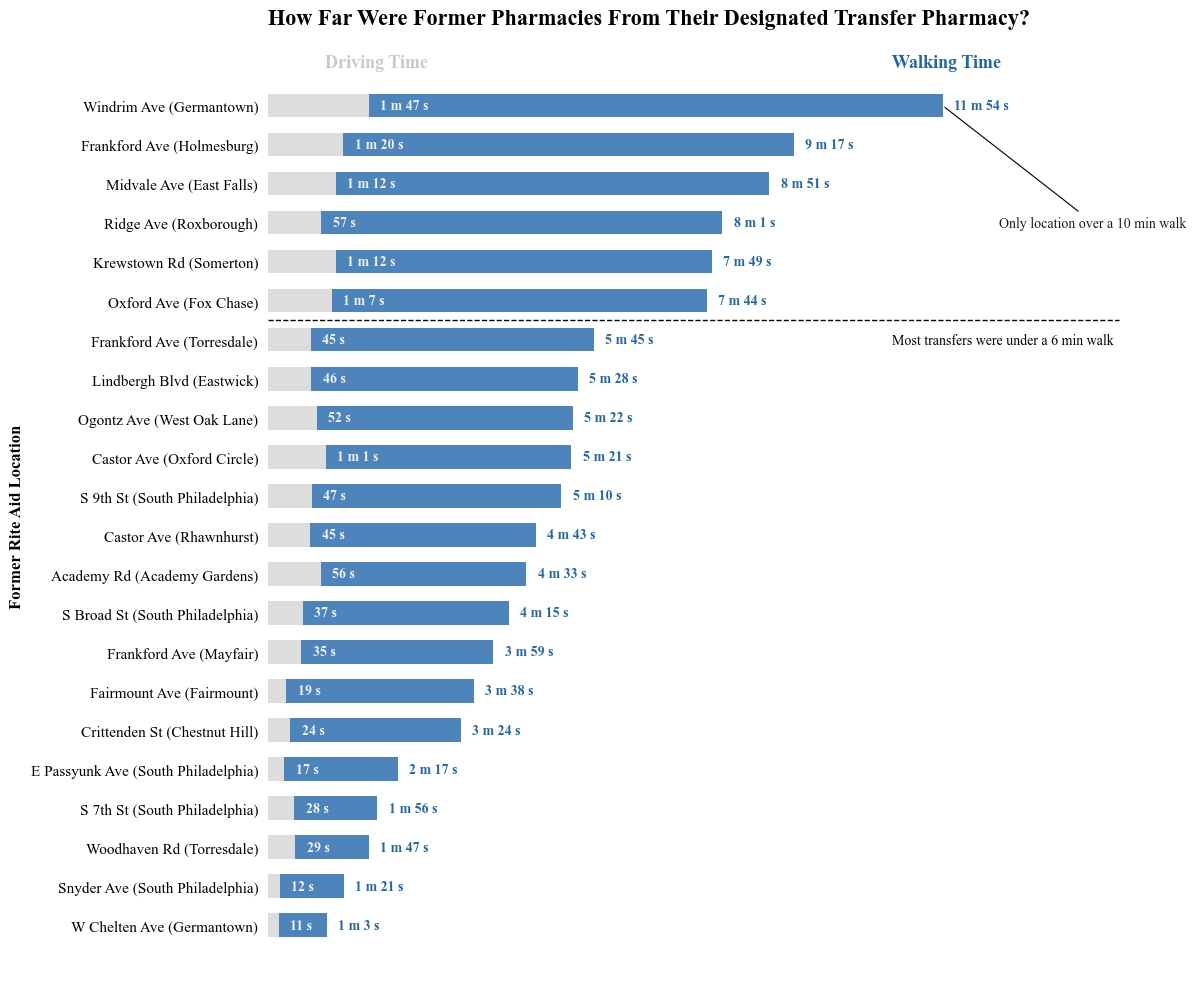

In [93]:
new_reproj = new_reproj.sort_values("walk_time_min", ascending=True)
fig, ax = plt.subplots(figsize=(12, 10))

plt.rcParams["font.family"] = "Times New Roman"

walk_color = "#2166AC"
drive_color = "#dddddd"

# Thicker bars using height parameter
ax.barh(new_reproj["Neighborhood Name"].astype(str), 
        new_reproj["walk_time_min"], 
        color=walk_color,
        alpha=0.80,
        height=0.6)
ax.barh(new_reproj["Neighborhood Name"].astype(str), 
        new_reproj["drive_time_min"],
        color=drive_color,
        height=0.6)

# Add time annotation onto the bars in minutes and seconds 
for i, (idx, row) in enumerate(new_reproj.iterrows()):
    # Walk time label
    if row["walk_time_min"] < 1:
        walk_label = f'{round(row["walk_time_min"] * 60)} s'
    else:
        whole_min = int(row["walk_time_min"])
        seconds = round((row["walk_time_min"] - whole_min) * 60)
        walk_label = f'{whole_min} m {seconds} s'
    
    # Drive time label
    if row["drive_time_min"] < 1:
        drive_label = f'{round(row["drive_time_min"] * 60)} s'
    else:
        whole_min = int(row["drive_time_min"])
        seconds = round((row["drive_time_min"] - whole_min) * 60)
        drive_label = f'{whole_min} m {seconds} s'

    ax.text(row["walk_time_min"] + 0.2, i, 
            walk_label,
            va="center", ha="left", fontsize=10,
            color=walk_color, fontweight="bold", zorder=4)
    ax.text(row["drive_time_min"] + 0.2, i,
            drive_label,
            va="center", ha="left", fontsize=10,
            color="#f0f0f0", fontweight="bold", zorder=4)
    
# Formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.xaxis.grid(False)
ax.set_xticks([])

# Title
ax.set_title("How Far Were Former Pharmacies From Their Designated Transfer Pharmacy?",
             fontsize=16, fontweight="bold", loc="left", pad=20, x=0)
ax.tick_params(axis="y", labelsize=11, colors="#000000")
ax.set_ylabel("Former Rite Aid Location", fontsize=12, color="#000000", fontweight="bold")

# Walking/driving labels spaced apart under title
ax.annotate("Walking Time",
            xy=(11, len(new_reproj)),
            fontsize=13, color=walk_color, fontweight="bold")
ax.annotate("Driving Time",
            xy=(1, len(new_reproj)),
            fontsize=13, color="#c9c9c9", fontweight="bold")

# Label for the Germantown location with a transfer pharmacy over a 10 minute walk away
germantown_idx = new_reproj["walk_time_min"].idxmax()
germantown_label = new_reproj.loc[germantown_idx, "Neighborhood Name"]
germantown_time = new_reproj.loc[germantown_idx, "walk_time_min"]
y_pos = list(new_reproj["Neighborhood Name"]).index(germantown_label)

ax.annotate("Only location over a 10 min walk", 
            xy=(germantown_time, y_pos),
            xytext=(germantown_time + 1, y_pos - 3),
            fontsize=10, color="#1a1a1a",
            arrowprops=dict(arrowstyle="-", color="000000", lw=0.8),
            va="center", ha="left")

ax.plot([0, 15], [15.5, 15.5], color="#000000", linewidth=1, linestyle="--")
ax.text(11, 15, "Most transfers were under a 6 min walk", 
        fontsize=10, color="#000000", va="center")

plt.tight_layout()
plt.savefig("FormerPharmDistance.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## 2. Changes in Population Served

Raw distance measures alone do not fully capture the burden that transfer locations impose on residents or the pre‑existing patterns of pharmacy access. To better assess accessibility, the change in population within a 10‑minute walking distance was calculated and compared between older and newer pharmacy locations. This approach allowed us to evaluate whether the demographic composition of residents with access shifted at the census‑tract level. The resulting plot of three vulnerable populations by former store locations shows that, despite new stores being only minutes away, overall fewer vulnerable residents were served at the locations of the transfers. Notably, one store in Center City demonstrated a tremendous increase in coverage for residents without a vehicle followed by a slight increase for elderly residents, even as coverage declined for the disabled groups.

In [21]:
#| output: false
# Calculate differences in population changes 
pop_change = pd.DataFrame({
    "elder_diff": new_buffer_pop["elder_pop_est"]- old_buffer_pop["elder_pop_est"],
    "vehicle_diff": new_buffer_pop["vehicle_pop_est"] - old_buffer_pop["vehicle_pop_est"],
    "disabled_diff": new_buffer_pop["disabled_pop_est"] - old_buffer_pop["disabled_pop_est"]
})

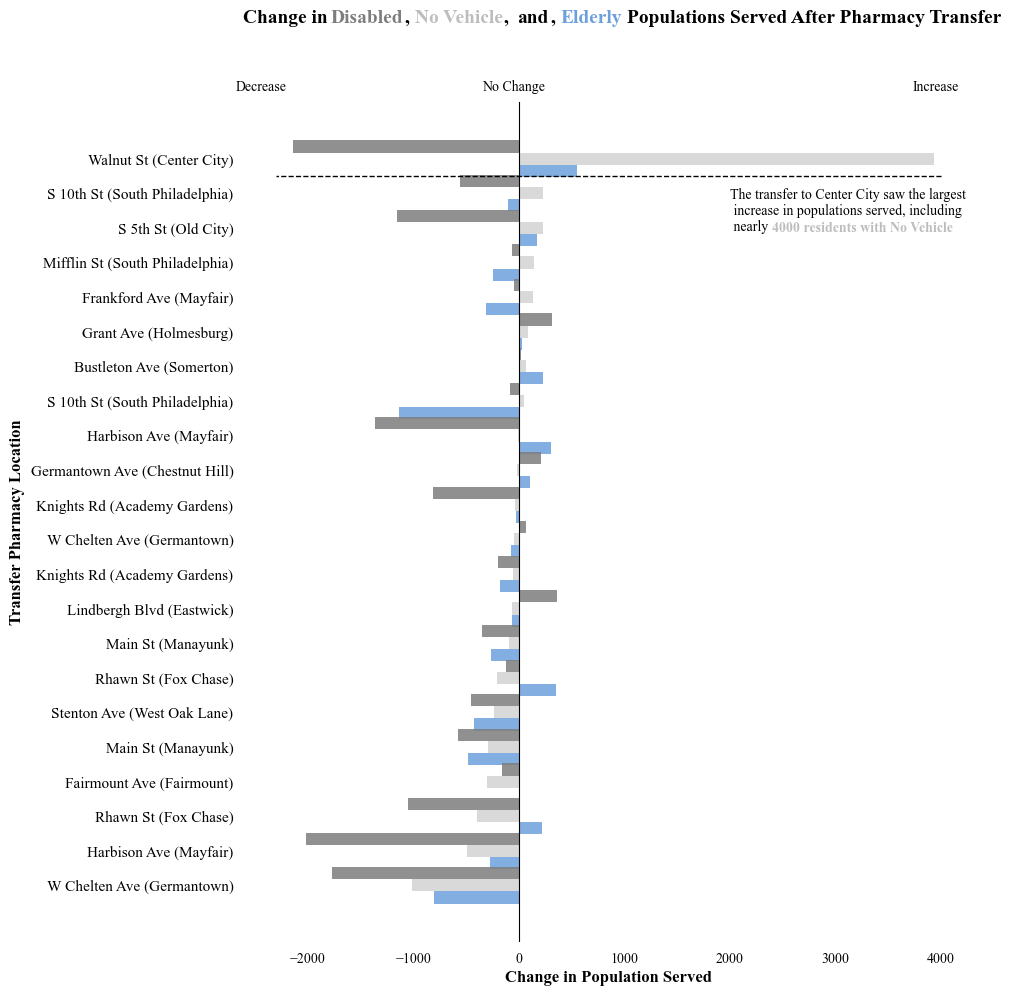

In [145]:
# Plot differences in population changes by former store locations

new_neighborhood_map = {
    "11136": "W Chelten Ave (Germantown)",
    "1941": "Stenton Ave (West Oak Lane)",
    "7834": "Frankford Ave (Mayfair)",
    "872": "W Chelten Ave (Germantown)",
    "1956": "Knights Rd (Academy Gardens)",
    "3637": "Harbison Ave (Mayfair)",
    "1936": "S 10th St (South Philadelphia)",
    "11139": "Harbison Ave (Mayfair)",
    "1766": "Mifflin St (South Philadelphia)",
    "11126": "Grant Ave (Holmesburg)",
    "11125": "Rhawn St (Fox Chase)",
    "3825": "Walnut St (Center City)",
    "11141": "Knights Rd (Academy Gardens)",
    "479": "Lindbergh Blvd (Eastwick)",
    "554": "Bustleton Ave (Somerton)",
    "3251": "Main St (Manayunk)",
    "4938": "Rhawn St (Fox Chase)",
    "11130": "Germantown Ave (Chestnut Hill)",
    "3434": "Fairmount Ave (Fairmount)",
    "3801": "S 5th St (Old City)",
    "822": "Main St (Manayunk)",
    "3325": "S 10th St (South Philadelphia)"
}

pop_change["New Neighborhood Name"] = pop_change.index.astype(str).map(new_neighborhood_map)

pop_change = pop_change.sort_values(
    by=["vehicle_diff", "disabled_diff", "elder_diff"],
    ascending=True
)

plt.rcParams["font.family"] = "Times New Roman"

x = np.arange(len(pop_change))  
width = 0.35

elder_color = "#6ca0dc"    # blue
vehicle_color = "#d3d3d3"  # gray
disabled_color = "#7d7d7d" # darker gray

fig, ax = plt.subplots(figsize=(10, 10))

# Horizontal bars
ax.barh(x - width, pop_change["elder_diff"], width, 
        label="Elderly", color=elder_color, alpha=0.85)
ax.barh(x, pop_change["vehicle_diff"], width, 
        label="No Vehicle", color=vehicle_color, alpha=0.85)
ax.barh(x + width, pop_change["disabled_diff"], width, 
        label="Disabled", color=disabled_color, alpha=0.85)

# Zero line — now vertical since bars are horizontal
ax.axvline(0, color="black", linewidth=0.8)

# NYT-style formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.xaxis.grid(False)

# Use neighborhood names instead of store numbers
ax.set_yticks(x)
ax.set_yticklabels(pop_change["New Neighborhood Name"], fontsize=11, color="#000000")

# Title and labels
ax.set_xlabel("Change in Population Served", fontsize=12, fontweight="bold", color="#000000")
ax.set_ylabel("Transfer Pharmacy Location", fontsize=12, fontweight="bold", color="#000000")

ax.text(0, 1.09, "Change in", fontsize=14, fontweight="bold", 
        color="#000000", transform=ax.transAxes, ha="left", va="bottom")
ax.text(0.12, 1.09, "Disabled", fontsize=14, fontweight="bold", 
        color=disabled_color, transform=ax.transAxes, ha="left", va="bottom")
ax.text(0.22, 1.09, ",", fontsize=14, fontweight="bold", 
        color="#000000", transform=ax.transAxes, ha="left", va="bottom")
ax.text(0.235, 1.09, "No Vehicle", fontsize=14, fontweight="bold", 
        color="#BDBDBD", transform=ax.transAxes, ha="left", va="bottom")
ax.text(0.356, 1.09, ",", fontsize=14, fontweight="bold", 
        color="#000000", transform=ax.transAxes, ha="left", va="bottom")
ax.text(0.375, 1.09, "and", fontsize=14, fontweight="bold", 
        color="#000000", transform=ax.transAxes, ha="left", va="bottom")
ax.text(0.42, 1.09, ",", fontsize=14, fontweight="bold", 
        color="#000000", transform=ax.transAxes, ha="left", va="bottom")
ax.text(0.435, 1.09, "Elderly", fontsize=14, fontweight="bold", 
        color=elder_color, transform=ax.transAxes, ha="left", va="bottom")
ax.text(0.525, 1.09, "Populations Served After Pharmacy Transfer", 
        fontsize=14, fontweight="bold", color="#000000", 
        transform=ax.transAxes, ha="left", va="bottom")

ax.text(-0.01, 1.01, "Decrease", fontsize=10, color="#000000", 
        ha="left", va="bottom", transform=ax.transAxes)
ax.text(0.37, 1.01, "No Change", fontsize=10, color="#000000", 
        ha="center", va="bottom", transform=ax.transAxes)
ax.text(0.98, 1.01, "Increase", fontsize=10, color="#000000", 
        ha="right", va="bottom", transform=ax.transAxes)

ax.plot([4000, -2300], [20.5, 20.5], color="#000000", linewidth=1, linestyle="--")
ax.text(2000, 19.5, "The transfer to Center City saw the largest\n increase in populations served, including\n nearly", 
        fontsize=10, color="#000000", va="center")
ax.text(2400, 19, "4000 residents with No Vehicle", 
        fontsize=10, fontweight="bold", color="#BDBDBD", va="center")


plt.tight_layout()
plt.show()

# Conclusion 
This analysis demonstrates that pharmacy transfers in Philadelphia generally increased the travel burden for residents, with former locations more likely to serve vulnerable populations such as elderly adults, residents without vehicles, and individuals with disabilities. Although transfer pharmacies remained within short driving distances, walking accessibility declined for many neighborhoods, underscoring the inequities introduced by closures. These findings suggest that former pharmacy sites played a critical role in supporting populations with limited mobility and transportation options. 

# Limitations 
At the same time, several limitations should be noted. The use of buffer‑based measures provides a consistent proxy for accessibility but cannot fully capture lived barriers such as transit availability. In addition, the absence of a pre‑existing spatial dataset required geocoding and custom network analysis, which may introduce error or bias depending on address accuracy and estimating location based on the nearest node. Despite these constraints, the combined use of street‑network distances and population density estimates offers a valuable framework for evaluating how pharmacy transfers reshape access and highlights the need for more equitable planning in the future.